# Mandetory Assignment 1: Training and Evaluating Baseline Models
#### Group: Prakmas

In [2]:
from tokenize import String

# Import the required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder

## Description of the dataset
This dataset that we ended up choosing is the "Student Performance Factors".
"The dataset provides a comprehensive overview of various factors affecting student performance in exams.
It includes information on study habits, attendance, parental involvement, and other aspects influencing academic success." - https://www.kaggle.com/datasets/lainguyn123/student-performance-factors

The target value is the exam score. To create a classification problem out of the dataset, this value will be encoded into categorical data.

In [3]:
# Read the dataset
student_dataset = pd.read_csv('Dataset/StudentPerformanceFactors.csv')
# Uses existing column names baked into csv file.

# Show the first 5 rows to validate that the data import has been successful
student_dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
# Read the dataset
student_dataset = pd.read_csv('Dataset/StudentPerformanceFactors.csv')
# Uses existing column names baked into csv file.

# Show the first 5 rows to validate that the data import has been successful
student_dataset.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [5]:
# Look at the implementation details, data types and missing data
student_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

### Missing Values


In [6]:
# Count the number of missing values in the dataset
student_dataset.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
# Check how many rows include at least one missing value.
student_dataset.isna().any(axis=1).sum()


np.int64(229)

In [8]:
# Remove rows with missing values from the student performance dataset.
student_dataset = student_dataset.dropna()

# Check to see if there still are features with missing values.
student_dataset.isna().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

In [9]:
# Separate the dataset into features and targets

features = student_dataset.drop('Parental_Involvement', axis=1)
targets = student_dataset['Parental_Involvement']

## Encoding
### Features



In [10]:
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
student_dataset['Parental_Involvement_Encoded'] = encoder.fit_transform(student_dataset[['Parental_Involvement']])
print(student_dataset[['Parental_Involvement','Parental_Involvement_Encoded']])

     Parental_Involvement  Parental_Involvement_Encoded
0                     Low                           0.0
1                     Low                           0.0
2                  Medium                           1.0
3                     Low                           0.0
4                  Medium                           1.0
...                   ...                           ...
6602                 High                           2.0
6603                 High                           2.0
6604               Medium                           1.0
6605                 High                           2.0
6606               Medium                           1.0

[6378 rows x 2 columns]


In [11]:
# Access to Resources

encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
student_dataset['Access_to_Resources_Encoded'] = encoder.fit_transform(student_dataset[['Access_to_Resources']])
print(student_dataset[['Access_to_Resources','Access_to_Resources_Encoded']])

     Access_to_Resources  Access_to_Resources_Encoded
0                   High                          2.0
1                 Medium                          1.0
2                 Medium                          1.0
3                 Medium                          1.0
4                 Medium                          1.0
...                  ...                          ...
6602              Medium                          1.0
6603              Medium                          1.0
6604                 Low                          0.0
6605                High                          2.0
6606                 Low                          0.0

[6378 rows x 2 columns]


In [12]:
# Extra Curricular Activities
encoder = OrdinalEncoder()
student_dataset['Extracurricular_Activities_Encoded'] = encoder.fit_transform(student_dataset[['Extracurricular_Activities']])
print(student_dataset[['Extracurricular_Activities', 'Extracurricular_Activities_Encoded']])


     Extracurricular_Activities  Extracurricular_Activities_Encoded
0                            No                                 0.0
1                            No                                 0.0
2                           Yes                                 1.0
3                           Yes                                 1.0
4                           Yes                                 1.0
...                         ...                                 ...
6602                         No                                 0.0
6603                         No                                 0.0
6604                        Yes                                 1.0
6605                        Yes                                 1.0
6606                        Yes                                 1.0

[6378 rows x 2 columns]


In [13]:
# Motivation_Level
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
student_dataset['Motivation_Level_Encoded'] = encoder.fit_transform(student_dataset[['Motivation_Level']])
print(student_dataset[['Motivation_Level', 'Motivation_Level_Encoded']])

     Motivation_Level  Motivation_Level_Encoded
0                 Low                       0.0
1                 Low                       0.0
2              Medium                       1.0
3              Medium                       1.0
4              Medium                       1.0
...               ...                       ...
6602           Medium                       1.0
6603           Medium                       1.0
6604              Low                       0.0
6605             High                       2.0
6606           Medium                       1.0

[6378 rows x 2 columns]


In [14]:
# Internet_Access
encoder = OrdinalEncoder()
student_dataset['Internet_Access_Encoded'] = encoder.fit_transform(student_dataset[['Internet_Access']])
print(student_dataset[['Internet_Access', 'Internet_Access_Encoded']])

     Internet_Access  Internet_Access_Encoded
0                Yes                      1.0
1                Yes                      1.0
2                Yes                      1.0
3                Yes                      1.0
4                Yes                      1.0
...              ...                      ...
6602             Yes                      1.0
6603             Yes                      1.0
6604             Yes                      1.0
6605             Yes                      1.0
6606             Yes                      1.0

[6378 rows x 2 columns]


In [15]:
# Family_Income
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
student_dataset['Family_Income_Encoded'] = encoder.fit_transform(student_dataset[['Family_Income']])
print(student_dataset[['Family_Income', 'Family_Income_Encoded']])

     Family_Income  Family_Income_Encoded
0              Low                    0.0
1           Medium                    1.0
2           Medium                    1.0
3           Medium                    1.0
4           Medium                    1.0
...            ...                    ...
6602          High                    2.0
6603           Low                    0.0
6604           Low                    0.0
6605           Low                    0.0
6606        Medium                    1.0

[6378 rows x 2 columns]


In [16]:
# Techer_Quality
encoder = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])
student_dataset['Teacher_Quality_Encoded'] = encoder.fit_transform(student_dataset[['Teacher_Quality']])
print(student_dataset[['Teacher_Quality', 'Teacher_Quality_Encoded']])

# MISSING VALUES

     Teacher_Quality  Teacher_Quality_Encoded
0             Medium                      1.0
1             Medium                      1.0
2             Medium                      1.0
3             Medium                      1.0
4               High                      2.0
...              ...                      ...
6602          Medium                      1.0
6603            High                      2.0
6604          Medium                      1.0
6605          Medium                      1.0
6606          Medium                      1.0

[6378 rows x 2 columns]


In [17]:
# School_Type
encoder = OrdinalEncoder()
student_dataset['School_Type_Encoded'] = encoder.fit_transform(student_dataset[['School_Type']])
print(student_dataset[['School_Type', 'School_Type_Encoded']])

     School_Type  School_Type_Encoded
0         Public                  1.0
1         Public                  1.0
2         Public                  1.0
3         Public                  1.0
4         Public                  1.0
...          ...                  ...
6602      Public                  1.0
6603      Public                  1.0
6604      Public                  1.0
6605     Private                  0.0
6606      Public                  1.0

[6378 rows x 2 columns]


In [18]:
# Peer_Influence
encoder = OrdinalEncoder(categories=[['Negative', 'Neutral', 'Positive']])
student_dataset['Peer_Influence_Encoded'] = encoder.fit_transform(student_dataset[['Peer_Influence']])
print(student_dataset[['Peer_Influence', 'Peer_Influence_Encoded']])


     Peer_Influence  Peer_Influence_Encoded
0          Positive                     2.0
1          Negative                     0.0
2           Neutral                     1.0
3          Negative                     0.0
4           Neutral                     1.0
...             ...                     ...
6602       Positive                     2.0
6603       Positive                     2.0
6604       Negative                     0.0
6605       Positive                     2.0
6606       Positive                     2.0

[6378 rows x 2 columns]


In [19]:
# Learning_Disabilites
encoder = OrdinalEncoder()
student_dataset['Learning_Disabilities_Encoded'] = encoder.fit_transform(student_dataset[['Learning_Disabilities']])
print(student_dataset[['Learning_Disabilities', 'Learning_Disabilities_Encoded']])

     Learning_Disabilities  Learning_Disabilities_Encoded
0                       No                            0.0
1                       No                            0.0
2                       No                            0.0
3                       No                            0.0
4                       No                            0.0
...                    ...                            ...
6602                    No                            0.0
6603                    No                            0.0
6604                    No                            0.0
6605                    No                            0.0
6606                    No                            0.0

[6378 rows x 2 columns]


In [20]:
# Parental_Education_Level

encoder = OrdinalEncoder(categories=[['High School', 'College', 'Postgraduate']])
student_dataset["Parental_Education_Level_encoded"] = encoder.fit_transform(student_dataset[["Parental_Education_Level"]]
)
print(student_dataset[["Parental_Education_Level", "Parental_Education_Level_encoded"]])
#MISSING VALUES

     Parental_Education_Level  Parental_Education_Level_encoded
0                 High School                               0.0
1                     College                               1.0
2                Postgraduate                               2.0
3                 High School                               0.0
4                     College                               1.0
...                       ...                               ...
6602              High School                               0.0
6603              High School                               0.0
6604             Postgraduate                               2.0
6605              High School                               0.0
6606             Postgraduate                               2.0

[6378 rows x 2 columns]


In [21]:
# Distance_from_Home
encoder = OrdinalEncoder(categories=[['Near', 'Moderate', 'Far']])
student_dataset["Distance_from_Home_Encoded"] = encoder.fit_transform(student_dataset[["Distance_from_Home"]]
)
print(student_dataset[["Distance_from_Home", "Distance_from_Home_Encoded"]])
#MISSING VALUES

     Distance_from_Home  Distance_from_Home_Encoded
0                  Near                         0.0
1              Moderate                         1.0
2                  Near                         0.0
3              Moderate                         1.0
4                  Near                         0.0
...                 ...                         ...
6602               Near                         0.0
6603               Near                         0.0
6604               Near                         0.0
6605                Far                         2.0
6606               Near                         0.0

[6378 rows x 2 columns]


In [22]:
# Gender
encoder = OrdinalEncoder()
student_dataset['Gender_Encoded'] = encoder.fit_transform(student_dataset[['Gender']])
print(student_dataset[['Gender', 'Gender_Encoded']])

      Gender  Gender_Encoded
0       Male             1.0
1     Female             0.0
2       Male             1.0
3       Male             1.0
4     Female             0.0
...      ...             ...
6602  Female             0.0
6603  Female             0.0
6604  Female             0.0
6605  Female             0.0
6606    Male             1.0

[6378 rows x 2 columns]


### Target value
#### Exam score
The exam score will first be translated into a category to make the task connected to the dataset into a classification problem.
This will be done by assigning grades to the exam scores.
Afterwards, the grades will be encoded using ordered encoding to preserve the grade order.

## Analysis
### Univariate Analysis

C:\Users\wilbn\AppData\Local\Temp\ipykernel_9548\1111027423.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  student_dataset.hist(ax=ax)


array([[<Axes: title={'center': 'Hours_Studied'}>,
        <Axes: title={'center': 'Attendance'}>,
        <Axes: title={'center': 'Sleep_Hours'}>,
        <Axes: title={'center': 'Previous_Scores'}>],
       [<Axes: title={'center': 'Tutoring_Sessions'}>,
        <Axes: title={'center': 'Physical_Activity'}>,
        <Axes: title={'center': 'Exam_Score'}>,
        <Axes: title={'center': 'Parental_Involvement_Encoded'}>],
       [<Axes: title={'center': 'Access_to_Resources_Encoded'}>,
        <Axes: title={'center': 'Extracurricular_Activities_Encoded'}>,
        <Axes: title={'center': 'Motivation_Level_Encoded'}>,
        <Axes: title={'center': 'Internet_Access_Encoded'}>],
       [<Axes: title={'center': 'Family_Income_Encoded'}>,
        <Axes: title={'center': 'Teacher_Quality_Encoded'}>,
        <Axes: title={'center': 'School_Type_Encoded'}>,
        <Axes: title={'center': 'Peer_Influence_Encoded'}>],
       [<Axes: title={'center': 'Learning_Disabilities_Encoded'}>,
       

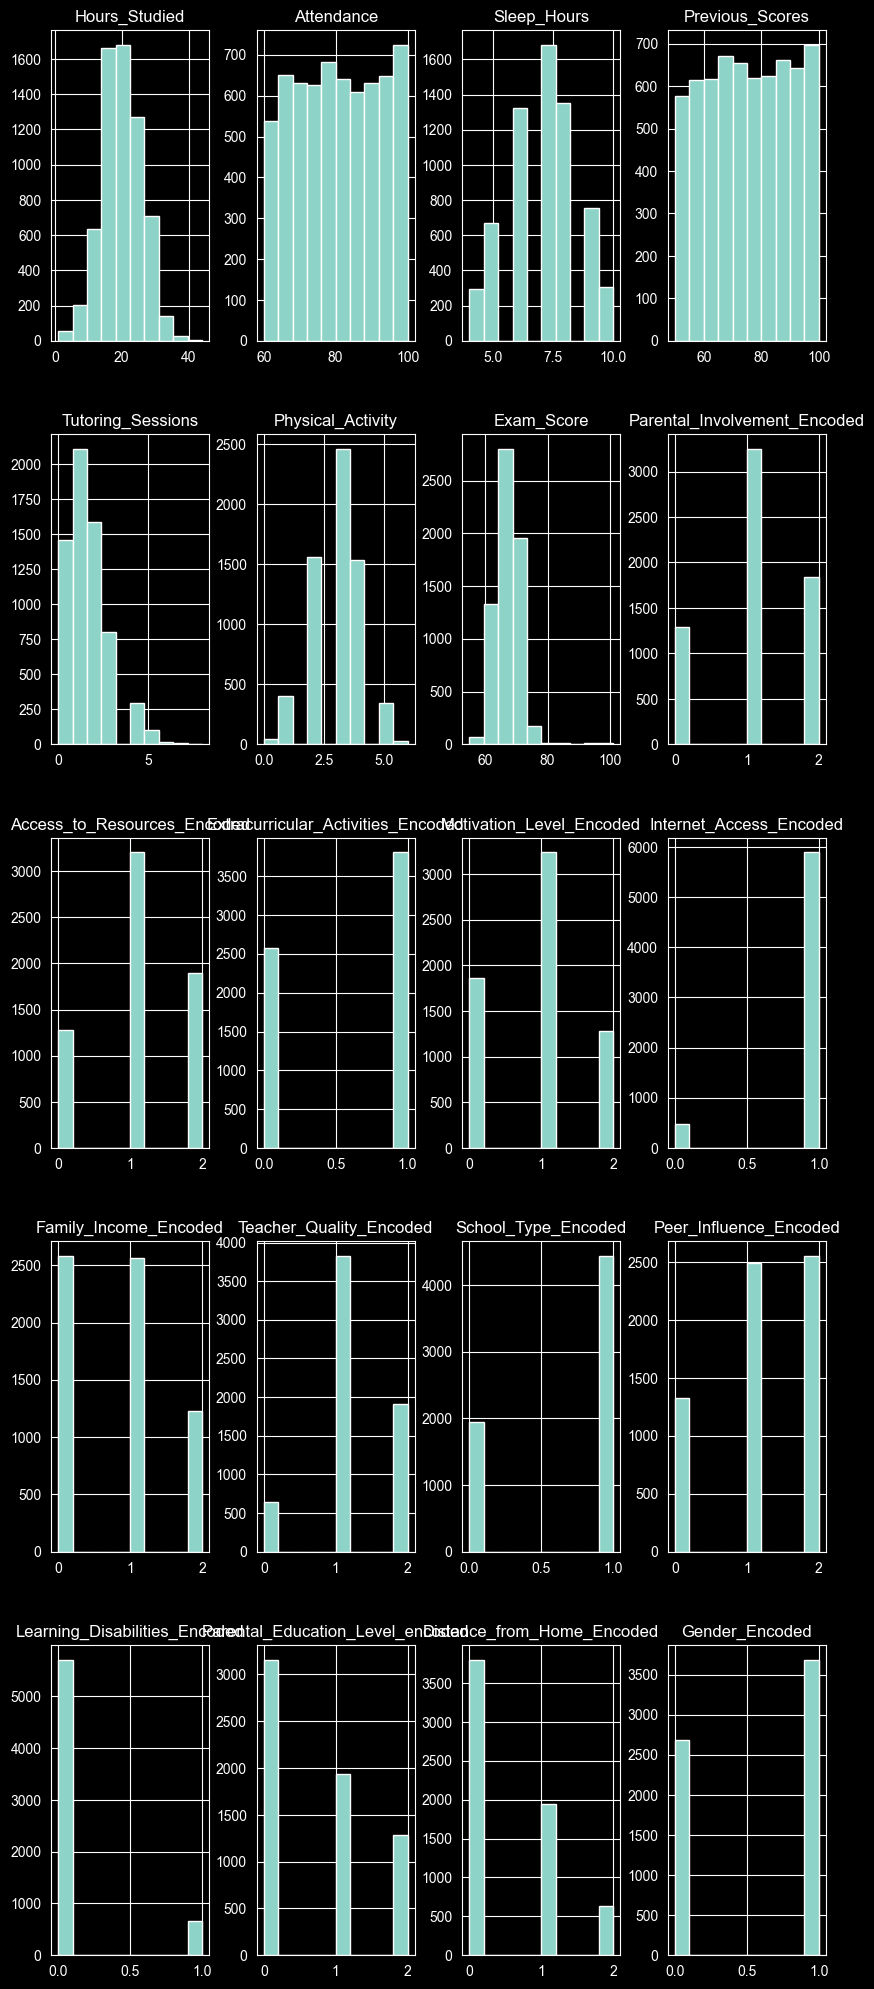

In [23]:
#Plotting the columns with numeric values into histograms
fig, ax = plt.subplots(1,1, figsize=(10,25))
student_dataset.hist(ax=ax)

array([[<Axes: title={'center': 'Previous_Scores'}>,
        <Axes: title={'center': 'Exam_Score'}>]], dtype=object)

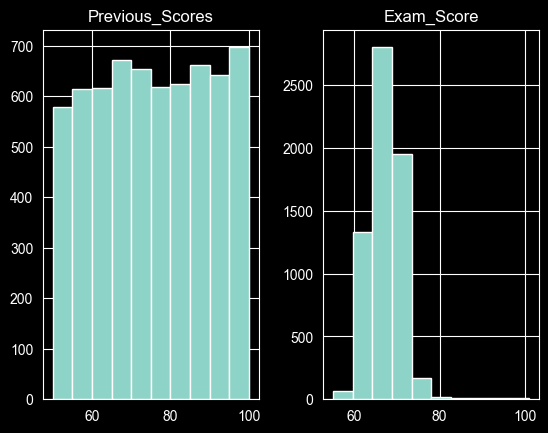

In [24]:
#Plotting a subset of the data to make it easier to analyze
student_dataset[['Previous_Scores', 'Exam_Score']].hist()

### Multivariate Analysis
In this part of the analysis, the features will be analyzed in relation to each other.
#### Correlation



<Axes: >

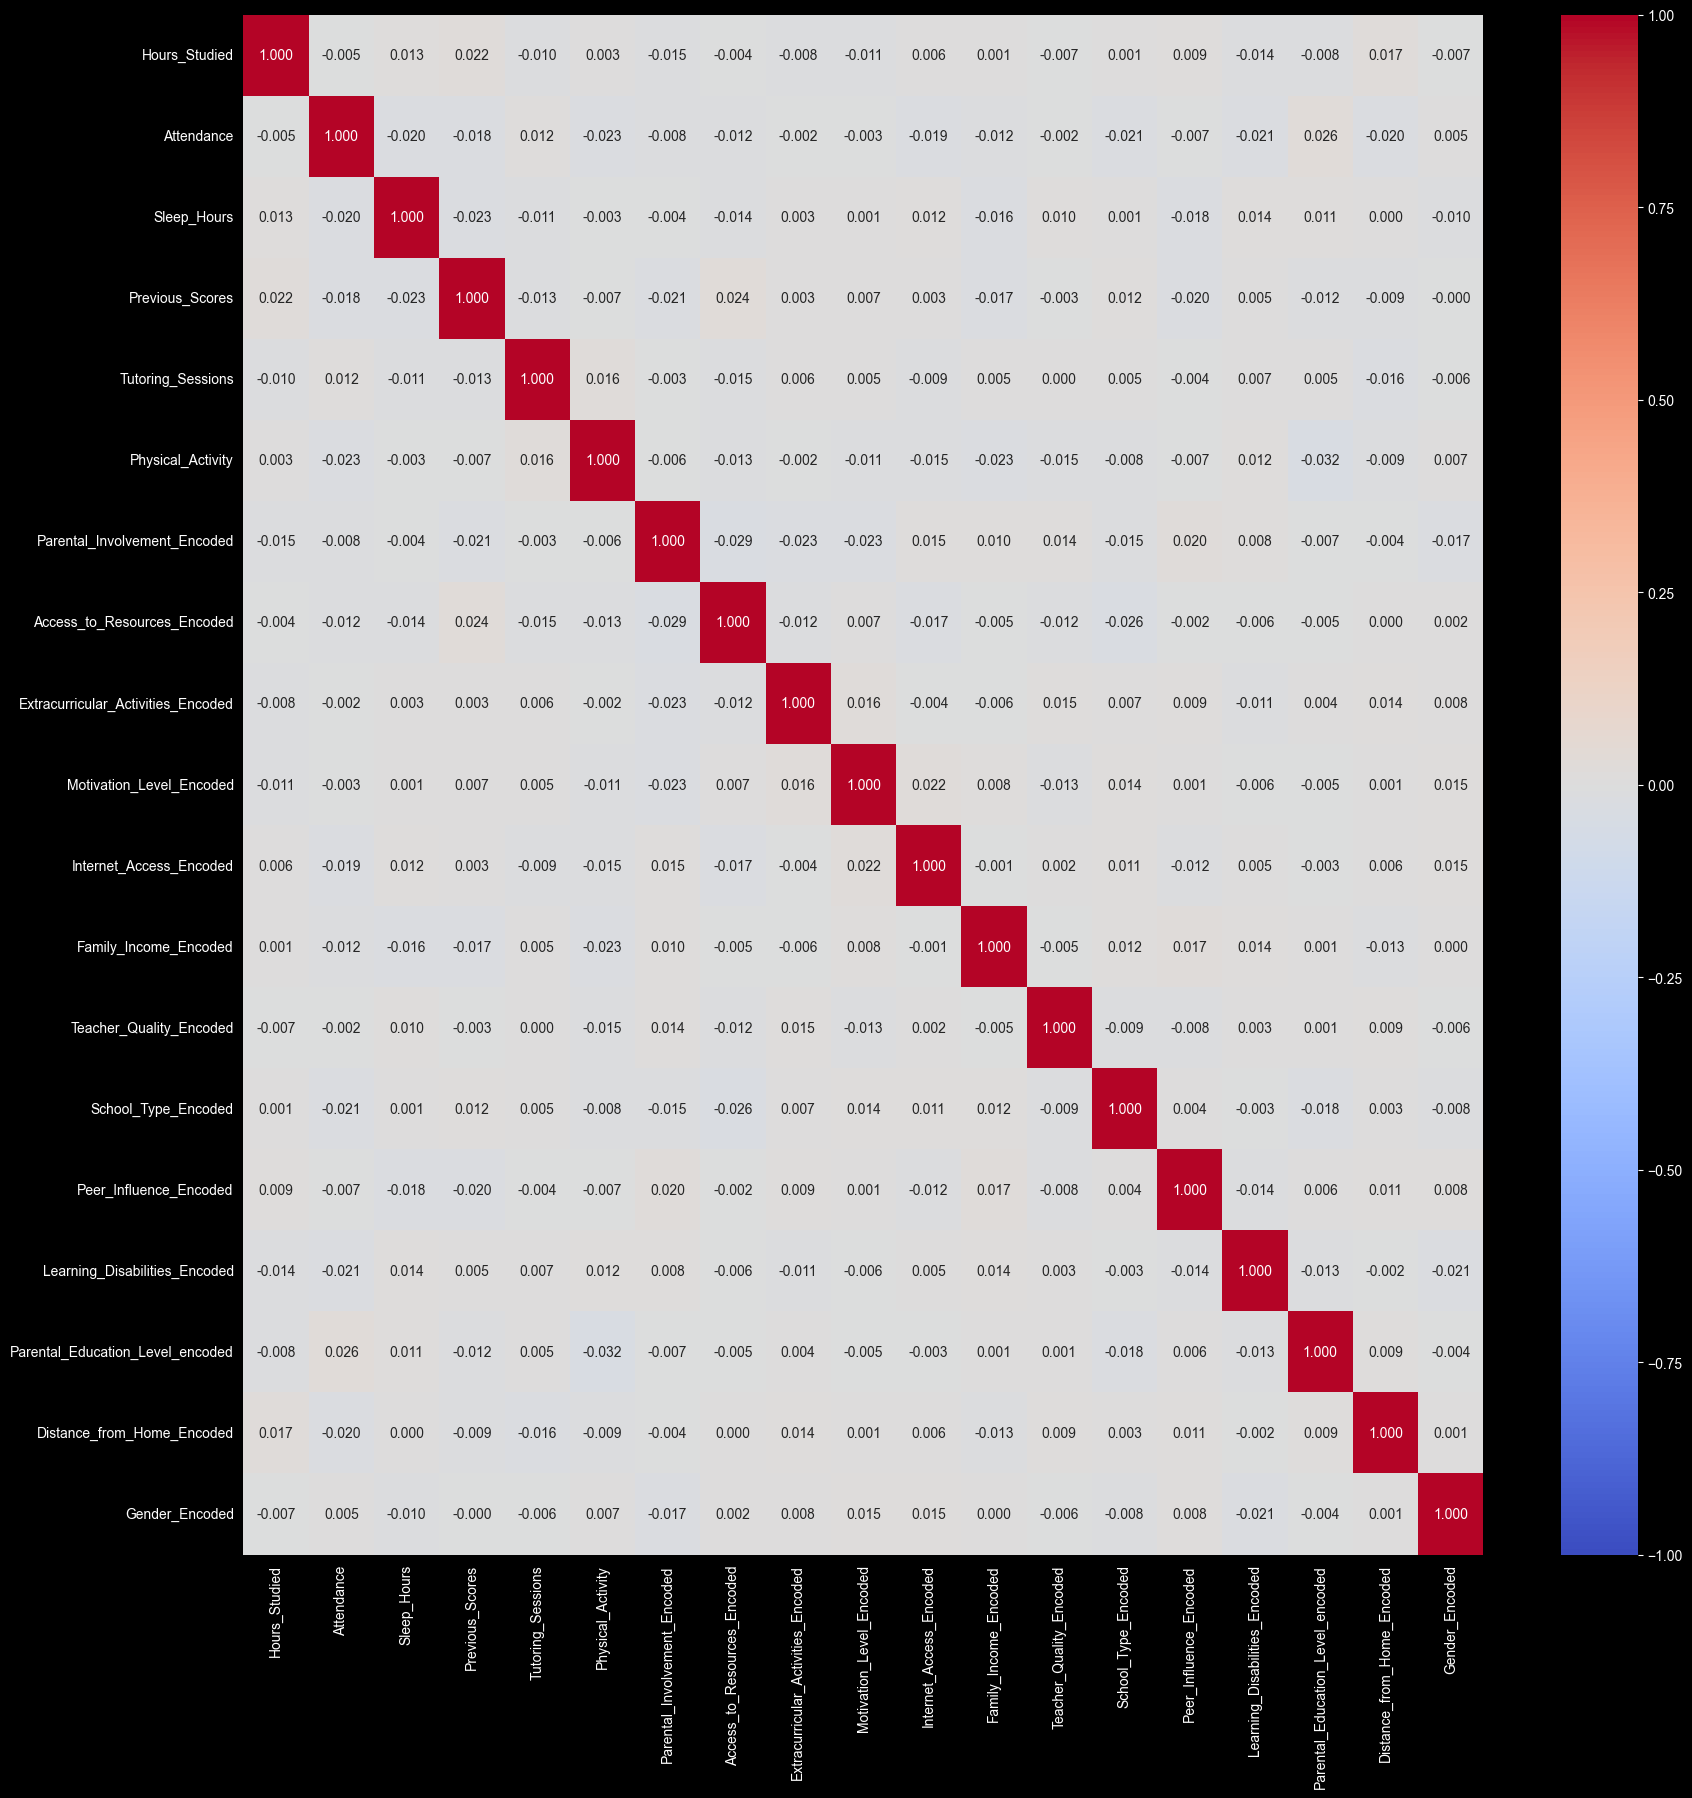

In [25]:
# Correlation gradient map.

# Computes the pairwise correlation between each feature.
# This method will only use numerical features.
correlation = student_dataset.drop('Exam_Score', axis=1).corr(numeric_only=True)

# Shows the correlation between the features in a heatmap.
plt.figure(figsize=(20, 20))
sns.heatmap(correlation, cmap='coolwarm', annot=True, fmt='.3f', vmin=-1, vmax=1)


#### Results
The results of the correlation graph shows that none of the features are correlated in any notable degree. This means that all the individual features provides unique data to the model, rather than a two or more features giving the same information and making them redundant.

### Scatterplot
To further investigate the correlation, can scatterplots be used. These will show the correlation between two features. The more linear the scatterplot is, the more correlated the features are. Since there is virtually no correlation between the features of the dataset, the scatterplots that will be shown are have many scattered dots. This is an indication of low correlation between features.

To showcase some scatterplots, pairs of features that might be thought to have correlation, if taking the domain into account, is shown.


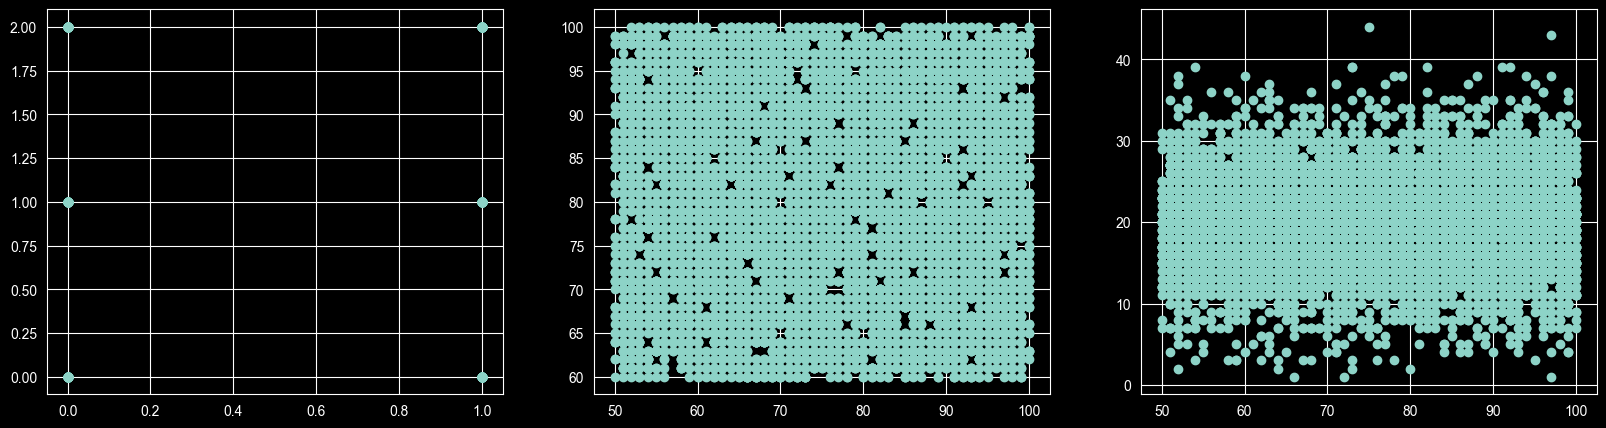

In [38]:
# Scatterplot.
fig, ax = plt.subplots(1, 3, figsize=(20,5))

ax[0].scatter(student_dataset['School_Type_Encoded'], student_dataset['Family_Income_Encoded'])
ax[1].scatter(student_dataset['Previous_Scores'], student_dataset['Attendance'])
ax[2].scatter(student_dataset['Previous_Scores'], student_dataset['Hours_Studied'])


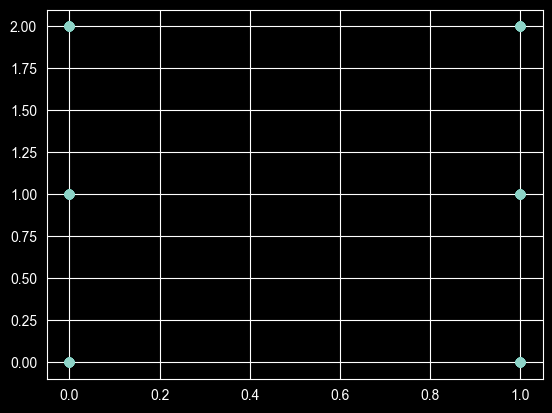

In [37]:
# Scatterplot test
plt.scatter(student_dataset['School_Type_Encoded'], student_dataset['Family_Income_Encoded'])

In [ ]:
# Encode the categorical target using one-hot encoding
# This would be the preferred way to encode (or dummy encoding) targets for 
# ML in general. Scikit learn does not require this. In fact, it can cause issues
# In scikit-learn, you should use LabelEncoder instead
# All categorical features must be encoded in general.
targets_onehot = pd.get_dummies(targets)
targets_onehot

In [ ]:
# Creates a new subset of the dataframe which excludes the non-encoded categorial data.
# This is needed for the baseline model inputs.
student_numerical_dataset = student_dataset.select_dtypes(exclude="string")

# Check to see if the new dataset includes  as intended.
student_numerical_dataset.head()